<a href="https://colab.research.google.com/github/AndrewPitblado/Walkability_Index_Analysis/blob/main/ECE9063_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Writes the Python script to the file system.
 It includes `argparse` for handling command-line arguments for input and output files, and contains all the cleaning and normalization logic.

In [1]:
%%writefile /content/clean_normalize_epa_data.py
"""
EPA Smart Location Database - Data Cleaning and Normalization Script
This script cleans and normalizes the EPA Smart Location Database V3 dataset.
"""

import pandas as pd
import numpy as np
import warnings
import argparse # Import argparse
warnings.filterwarnings('ignore')

def main():
    # Setup argparse
    parser = argparse.ArgumentParser(description='Clean and normalize EPA Smart Location Database V3.')
    parser.add_argument('--input', type=str, default='EPA_SmartLocationDatabase_V3_Jan_2021_Final.csv',
                        help='Path to the input EPA Smart Location Database CSV file.')
    parser.add_argument('--output_cleaned', type=str, default='EPA_SmartLocationDatabase_V3_CLEANED.csv',
                        help='Path to save the cleaned data CSV file.')
    parser.add_argument('--output_normalized', type=str, default='EPA_SmartLocationDatabase_V3_CLEANED_NORMALIZED.csv',
                        help='Path to save the cleaned and normalized data CSV file.')

    args = parser.parse_args()

    # Load the dataset
    print("Loading EPA Smart Location Database...")
    try:
        df = pd.read_csv(args.input)
    except FileNotFoundError:
        print(f"Error: Input file not found at {args.input}")
        return

    print(f"\nInitial dataset shape: {df.shape}")
    print(f"Total rows: {df.shape[0]:,}")
    print(f"Total columns: {df.shape[1]}")

    # ============================================================================
    # DATA QUALITY ASSESSMENT
    # ============================================================================
    print("\n" + "="*80)
    print("DATA QUALITY ASSESSMENT")
    print("="*80)

    # Check for duplicates
    duplicates = df.duplicated().sum()
    print(f"\n1. Duplicate rows: {duplicates}")

    # Check for missing values
    print("\n2. Missing values by column:")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing_Count': missing,
        'Missing_Percentage': missing_pct
    }).sort_values('Missing_Count', ascending=False)

    # Display only columns with missing values
    missing_with_nulls = missing_df[missing_df['Missing_Count'] > 0]
    if len(missing_with_nulls) > 0:
        print(missing_with_nulls.head(20))
    else:
        print("No missing values found!")

    # Check data types
    print("\n3. Data types summary:")
    print(df.dtypes.value_counts())

    # Check for potential issues with numeric columns stored as objects
    print("\n4. Checking for numeric columns stored as text...")
    object_cols = df.select_dtypes(include=['object']).columns
    problematic_cols = []
    for col in object_cols:
        # Skip obvious text columns
        if col in ['GEOID10', 'GEOID20', 'CSA_Name', 'CBSA_Name', 'STATEFP', 'COUNTYFP', 'TRACTCE', 'BLKGRPCE']:
            continue
        try:
            # Try to convert to numeric
            pd.to_numeric(df[col], errors='raise')
            problematic_cols.append(col)
        except:
            pass

    if problematic_cols:
        print(f"Found {len(problematic_cols)} numeric columns stored as text:")
        for col in problematic_cols[:10]:
            print(f"  - {col}")
    else:
        print("No obvious issues found.")

    # ============================================================================
    # DATA CLEANING
    # ============================================================================
    print("\n" + "="*80)
    print("DATA CLEANING")
    print("="*80)

    df_clean = df.copy()

    # 1. Remove exact duplicates
    print("\n1. Removing duplicate rows...")
    initial_rows = len(df_clean)
    df_clean = df_clean.drop_duplicates()
    removed_duplicates = initial_rows - len(df_clean)
    print(f"   Removed {removed_duplicates} duplicate rows")

    # 2. Handle missing values
    print("\n2. Handling missing values...")

    # Define columns to handle differently
    geographic_identifiers = ['CSA', 'CBSA', 'CSA_Name', 'CBSA_Name']
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        missing_count = df_clean[col].isnull().sum()
        if missing_count > 0:
            missing_pct = (missing_count / len(df_clean)) * 100

            # Skip CSA and CBSA - these should remain missing
            if col in geographic_identifiers:
                print(f"   {col}: {missing_count} missing values ({missing_pct:.2f}%) - KEPT AS MISSING (not in metro area)")
                continue

            # If more than 50% missing, flag as warning
            if missing_pct > 50:
                print(f"   WARNING: {col} has {missing_pct:.2f}% missing values")

            # Fill with 0 for counts/employment data, median for other metrics
            if any(x in col.upper() for x in ['EMP', 'POP', 'WORKERS', 'COUNT', 'HH', 'TOT']):
                df_clean[col].fillna(0, inplace=True)
                print(f"   Filled {col} missing values with 0 ({missing_count} values)")
            else:
                median_val = df_clean[col].median()
                df_clean[col].fillna(median_val, inplace=True)
                print(f"   Filled {col} missing values with median: {median_val:.4f} ({missing_count} values)")

    # Create binary indicators for CSA and CBSA membership
    print("\n2b. Creating metro area indicators...")
    df_clean['In_CSA'] = df_clean['CSA'].notna().astype(int)
    df_clean['In_CBSA'] = df_clean['CBSA'].notna().astype(int)
    print(f"   Created In_CSA: {df_clean['In_CSA'].sum():,} block groups in Combined Statistical Areas")
    print(f"   Created In_CBSA: {df_clean['In_CBSA'].sum():,} block groups in Core Based Statistical Areas")

    # 3. Fix data types - convert GEOID columns to strings to preserve leading zeros
    print("\n3. Fixing data types...")
    geoid_cols = ['GEOID10', 'GEOID20', 'STATEFP', 'COUNTYFP', 'TRACTCE', 'BLKGRPCE']
    for col in geoid_cols:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].astype(str)
            # Ensure proper formatting (e.g., state codes should be 2 digits)
            if col == 'STATEFP':
                df_clean[col] = df_clean[col].str.zfill(2)
            print(f"   Converted {col} to string type")

    # Convert CSA and CBSA to strings (categorical codes)
    if 'CSA' in df_clean.columns:
        df_clean['CSA'] = df_clean['CSA'].astype(str).replace('nan', np.nan)
        print(f"   Converted CSA to string type (categorical)")
    if 'CBSA' in df_clean.columns:
        df_clean['CBSA'] = df_clean['CBSA'].astype(str).replace('nan', np.nan)
        print(f"   Converted CBSA to string type (categorical)")

    # 4. Remove rows with invalid core identifiers
    print("\n4. Checking for invalid core identifiers...")
    initial_rows = len(df_clean)
    # Keep only rows where GEOID10 is valid (not null, not empty)
    df_clean = df_clean[df_clean['GEOID10'].notna()]
    df_clean = df_clean[df_clean['GEOID10'] != '']
    df_clean = df_clean[df_clean['GEOID10'] != 'nan']
    removed_invalid = initial_rows - len(df_clean)
    if removed_invalid > 0:
        print(f"   Removed {removed_invalid} rows with invalid identifiers")
    else:
        print("   No invalid identifiers found")

    # 5. Handle outliers in key numeric columns
    print("\n5. Detecting outliers in key numeric columns...")
    outlier_cols = ['TotPop', 'TotEmp', 'Workers', 'Ac_Land', 'Ac_Total']
    for col in outlier_cols:
        if col in df_clean.columns:
            Q1 = df_clean[col].quantile(0.25)
            Q3 = df_clean[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 3 * IQR  # Using 3*IQR for less aggressive filtering
            upper_bound = Q3 + 3 * IQR
            outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
            outlier_pct = (outliers / len(df_clean)) * 100
            print(f"   {col}: {outliers} potential outliers detected ({outlier_pct:.2f}%) - NOT REMOVED (may be real extreme values)")

    # ============================================================================
    # DATA NORMALIZATION
    # ============================================================================
    print("\n" + "="*80)
    print("DATA NORMALIZATION")
    print("="*80)

    df_normalized = df_clean.copy()

    # 1. Create normalized versions of key metrics (0-1 scale)
    print("\n1. Creating normalized versions of key metrics...")
    metrics_to_normalize = [
        'TotPop', 'TotEmp', 'Workers', 'D1A', 'D1B', 'D1C',
        'D2A_JPHH', 'D3B', 'D4A', 'D5AR', 'D5AE'
    ]

    for col in metrics_to_normalize:
        if col in df_normalized.columns:
            col_min = df_normalized[col].min()
            col_max = df_normalized[col].max()
            if col_max - col_min > 0:  # Avoid division by zero
                df_normalized[f'{col}_normalized'] = (df_normalized[col] - col_min) / (col_max - col_min)
                print(f"   Created {col}_normalized")

    # 2. Standardize percentage columns (ensure they're between 0 and 1)
    print("\n2. Standardizing percentage columns...")
    pct_cols = [col for col in df_normalized.columns if 'Pct' in col or 'PCT' in col or col.startswith('P_')]
    for col in pct_cols:
        if df_normalized[col].max() > 1:
            # Convert from 0-100 to 0-1 scale
            df_normalized[col] = df_normalized[col] / 100
            print(f"   Standardized {col} to 0-1 scale")

    # 3. Create density categories
    print("\n3. Creating categorical variables from continuous metrics...")
    if 'D1A' in df_normalized.columns:
        df_normalized['PopDensity_Category'] = pd.cut(
            df_normalized['D1A'],
            bins=[0, 1, 5, 10, 20, float('inf')],
            labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
        )
        print("   Created PopDensity_Category")

    if 'D1B' in df_normalized.columns:
        df_normalized['EmpDensity_Category'] = pd.cut(
            df_normalized['D1B'],
            bins=[0, 1, 5, 10, 20, float('inf')],
            labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
        )
        print("   Created EmpDensity_Category")

    if 'NatWalkInd' in df_normalized.columns:
        df_normalized['Walkability_Category'] = pd.cut(
            df_normalized['NatWalkInd'],
            bins=[0, 5, 10, 15, 20],
            labels=['Low', 'Medium', 'High', 'Very High'],
            include_lowest=True
        )
        print("   Created Walkability_Category")

    # Create urban/rural classification based on metro area membership
    print("\n3b. Creating urban/rural classification...")
    df_normalized['Urban_Rural'] = 'Rural'
    df_normalized.loc[df_normalized['In_CBSA'] == 1, 'Urban_Rural'] = 'Urban'
    urban_count = (df_normalized['Urban_Rural'] == 'Urban').sum()
    rural_count = (df_normalized['Urban_Rural'] == 'Rural').sum()
    print(f"   Created Urban_Rural: {urban_count:,} Urban, {rural_count:,} Rural")

    # 4. Create derived metrics
    print("\n4. Creating derived metrics...")
    # Employment-Population ratio
    if 'TotEmp' in df_normalized.columns and 'TotPop' in df_normalized.columns:
        df_normalized['Emp_Pop_Ratio'] = df_normalized['TotEmp'] / df_normalized['TotPop'].replace(0, np.nan)
        print("   Created Emp_Pop_Ratio")

    # Workers per household
    if 'Workers' in df_normalized.columns and 'HH' in df_normalized.columns:
        df_normalized['Workers_Per_HH'] = df_normalized['Workers'] / df_normalized['HH'].replace(0, np.nan)
        print("   Created Workers_Per_HH")

    # ============================================================================
    # SAVE CLEANED AND NORMALIZED DATA
    # ============================================================================
    print("\n" + "="*80)
    print("SAVING RESULTS")
    print("="*80)

    # Save cleaned data
    output_file_clean = args.output_cleaned
    df_clean.to_csv(output_file_clean, index=False)
    print(f"\n\u2713 Cleaned data saved to: {output_file_clean}")
    print(f"  Shape: {df_clean.shape}")

    # Save cleaned and normalized data
    output_file_normalized = args.output_normalized
    df_normalized.to_csv(output_file_normalized, index=False)
    print(f"\n\u2713 Cleaned and normalized data saved to: {output_file_normalized}")
    print(f"  Shape: {df_normalized.shape}")

    # Create a data quality report
    print("\n" + "="*80)
    print("FINAL DATA QUALITY SUMMARY")
    print("="*80)
    print(f"\nOriginal dataset: {df.shape[0]:,} rows \u00d7 {df.shape[1]} columns")
    print(f"Cleaned dataset: {df_clean.shape[0]:,} rows \u00d7 {df_clean.shape[1]} columns")
    print(f"Normalized dataset: {df_normalized.shape[0]:,} rows \u00d7 {df_normalized.shape[1]} columns")
    print(f"\nRows removed: {df.shape[0] - df_clean.shape[0]:,}")
    print(f"New columns added: {df_normalized.shape[1] - df_clean.shape[1]}")

    # Metro area summary
    print("\n" + "="*80)
    print("METRO AREA COVERAGE")
    print("="*80)
    print(f"Block groups in Combined Statistical Areas (CSA): {df_clean['In_CSA'].sum():,} ({(df_clean['In_CSA'].sum()/len(df_clean)*100):.1f}%)")
    print(f"Block groups in Core Based Statistical Areas (CBSA): {df_clean['In_CBSA'].sum():,} ({(df_clean['In_CBSA'].sum()/len(df_clean)*100):.1f}%))")
    print(f"Rural block groups (not in CBSA): {(df_clean['In_CBSA']==0).sum():,} ({((df_clean['In_CBSA']==0).sum()/len(df_clean)*100):.1f}%))")

    # Summary statistics for key columns
    print("\n" + "="*80)
    print("KEY STATISTICS (Cleaned Data)")
    print("="*80)
    key_stats_cols = ['TotPop', 'TotEmp', 'Workers', 'HH', 'D1A', 'D1B', 'NatWalkInd']
    existing_stats_cols = [col for col in key_stats_cols if col in df_clean.columns]
    if existing_stats_cols:
        print(df_clean[existing_stats_cols].describe())

    print("\n\u2713 Data cleaning and normalization complete!")
    print("\nFiles created:")
    print(f"  1. {output_file_clean}")
    print(f"  2. {output_file_normalized}")
    print("\nKey improvements:")
    print("  \u2022 CSA and CBSA codes preserved as missing where appropriate")
    print("  \u2022 Created In_CSA and In_CBSA binary indicators for analysis")
    print("  \u2022 Created Urban_Rural classification based on CBSA membership")
    print("  \u2022 All geographic identifiers properly formatted as strings")

if __name__ == '__main__':
    main()

Writing /content/clean_normalize_epa_data.py


## 2. Run the `clean_normalize_epa_data.py` script

This command executes the Python script using a sample input file. The script will use its default output filenames for the cleaned and normalized CSV files. The output of the script will be displayed below.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
input_file = '/content/EPA_SmartLocationDatabase_V3_Jan_2021_Final copy.csv'

# Run the script with the input file. It will use its default output filenames.
!python /content/clean_normalize_epa_data.py --input "{input_file}"

Loading EPA Smart Location Database...

Initial dataset shape: (220740, 117)
Total rows: 220,740
Total columns: 117

DATA QUALITY ASSESSMENT

1. Duplicate rows: 0

2. Missing values by column:
           Missing_Count  Missing_Percentage
CSA_Name           53031           24.024191
CSA                53031           24.024191
CBSA_Name          17095            7.744405
CBSA               17095            7.744405
D1C8_OFF             605            0.274078
CountHU              275            0.124581
HH                   275            0.124581
D1A                  271            0.122769
GEOID10                1            0.000453
D4E                    1            0.000453
D4D                    1            0.000453

3. Data types summary:
float64    73
int64      42
object      2
Name: count, dtype: int64

4. Checking for numeric columns stored as text...
No obvious issues found.

DATA CLEANING

1. Removing duplicate rows...
   Removed 0 duplicate rows

2. Handling missing valu

## 3. Load and explore `EPA_SmartLocationDatabase_V3_CLEANED.csv`

After the script has run and created the cleaned data file, we can load it into a pandas DataFrame and examine its contents.

In [4]:
import pandas as pd

cleaned_df = pd.read_csv('EPA_SmartLocationDatabase_V3_CLEANED.csv')

print("First 5 rows of the cleaned data:")
display(cleaned_df.head())

print("\nInformation about the cleaned data (data types and non-null counts):")
cleaned_df.info()

First 5 rows of the cleaned data:


,OBJECTID,GEOID10,GEOID20,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,CSA,CSA_Name,CBSA,...,D5DEI,D2A_Ranked,D2B_Ranked,D3B_Ranked,D4A_Ranked,NatWalkInd,Shape_Length,Shape_Area,In_CSA,In_CBSA
0,1,4.811300e+11,4.811300e+11,48,113,7825,4,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.137707,6,14,15,17,14.000000,3110.360820,297836.0831,1,1
1,2,4.811300e+11,4.811300e+11,48,113,7825,2,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.231868,3,10,12,14,10.833333,3519.469110,484945.1466,1,1
2,3,4.811300e+11,4.811300e+11,48,113,7825,3,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.213146,1,1,7,17,8.333333,1697.091802,106705.9281,1,1
3,4,4.811300e+11,4.811300e+11,48,113,7824,1,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.205018,16,10,17,17,15.666667,2922.609204,481828.4303,1,1
4,5,4.811300e+11,4.811300e+11,48,113,7824,2,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.125296,4,7,11,14,10.166667,3731.971773,687684.7752,1,1



Information about the cleaned data (data types and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220740 entries, 0 to 220739
Columns: 119 entries, OBJECTID to In_CBSA
dtypes: float64(73), int64(44), object(2)
memory usage: 200.4+ MB


## 4. Load and explore `EPA_SmartLocationDatabase_V3_CLEANED_NORMALIZED.csv`

Load the `EPA_SmartLocationDatabase_V3_CLEANED_NORMALIZED.csv` file into a pandas DataFrame, then display its first 5 rows and print its information (data types and non-null counts).

In [17]:
import pandas as pd

normalized_df = pd.read_csv('EPA_SmartLocationDatabase_V3_CLEANED_NORMALIZED.csv')

print("First 5 rows of the normalized data:")
display(normalized_df.head())

print("\nInformation about the normalized data (data types and non-null counts):")
normalized_df.info()

First 5 rows of the normalized data:


,OBJECTID,GEOID10,GEOID20,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,CSA,CSA_Name,CBSA,...,D3B_normalized,D4A_normalized,D5AR_normalized,D5AE_normalized,PopDensity_Category,EmpDensity_Category,Walkability_Category,Urban_Rural,Emp_Pop_Ratio,Workers_Per_HH
0,1,4.811300e+11,4.811300e+11,48,113,7825,4,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.021927,0.991652,0.355235,0.314884,Medium,High,High,Urban,0.054908,0.973995
1,2,4.811300e+11,4.811300e+11,48,113,7825,2,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.015152,0.995177,0.316650,0.282194,Low,Medium,High,Urban,0.035211,0.965770
2,3,4.811300e+11,4.811300e+11,48,113,7825,3,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.004589,0.992009,0.331454,0.299604,High,Very High,Medium,Urban,0.000000,1.407295
3,4,4.811300e+11,4.811300e+11,48,113,7824,1,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.026771,0.991890,0.346631,0.309075,Low,Medium,Very High,Urban,0.279867,1.122396
4,5,4.811300e+11,4.811300e+11,48,113,7824,2,206.0,"Dallas-Fort Worth, TX-OK",19100.0,...,0.012347,0.994381,0.275028,0.246969,Low,Medium,High,Urban,0.033755,1.688047



Information about the normalized data (data types and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220740 entries, 0 to 220739
Columns: 136 entries, OBJECTID to Workers_Per_HH
dtypes: float64(86), int64(44), object(6)
memory usage: 229.0+ MB



## 5. Feature Selection
Use the 5D framework features as predictors:
- **D1**: Density (population, employment, activity)
- **D2**: Diversity (jobs-housing balance, employment mix)
- **D3**: Design (street connectivity, intersections)
- **D4**: Distance to Transit
- **D5**: Destination Accessibility


In [18]:
# Define target variable
target = 'NatWalkInd'

# Define feature sets based on user's request
all_features = [
    'TotPop',
    'TotEmp',
    'Workers',
    'D1A',           # Population density
    'D1B',           # Employment density
    'D1C',           # Activity density
    'D2A_JPHH',      # Jobs per household
    'D3B',           # Street intersection density
    'D4A',           # Distance to nearest transit
    'D5AR',          # Jobs accessible by auto (residential)
    'D5AE'           # Jobs accessible by auto (employment)
]

print(f"Selected {len(all_features)} features for modeling")
print(f"Features: {all_features}")

Selected 11 features for modeling
Features: ['TotPop', 'TotEmp', 'Workers', 'D1A', 'D1B', 'D1C', 'D2A_JPHH', 'D3B', 'D4A', 'D5AR', 'D5AE']


In [7]:
from sklearn.model_selection import train_test_split # Import train_test_split

# Define X and y for the train-test split
X = normalized_df[all_features]
y = normalized_df[target]

# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("="*60)
print("TRAIN-TEST SPLIT")
print("="*60)
print(f"Training set size: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%))")
print(f"Test set size: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%))")
print(f"\nFeature matrix shape: {X_train.shape}")
print(f"Target vector shape: {y_train.shape}")

TRAIN-TEST SPLIT
Training set size: 176,592 (80.0%))
Test set size: 44,148 (20.0%))

Feature matrix shape: (176592, 11)
Target vector shape: (176592,)


TARGET VARIABLE: NatWalkInd


,NatWalkInd
count,220740.000000
mean,9.541628
std,4.373952
min,1.000000
25%,5.833333
50%,9.166667
75%,13.166667
max,20.000000


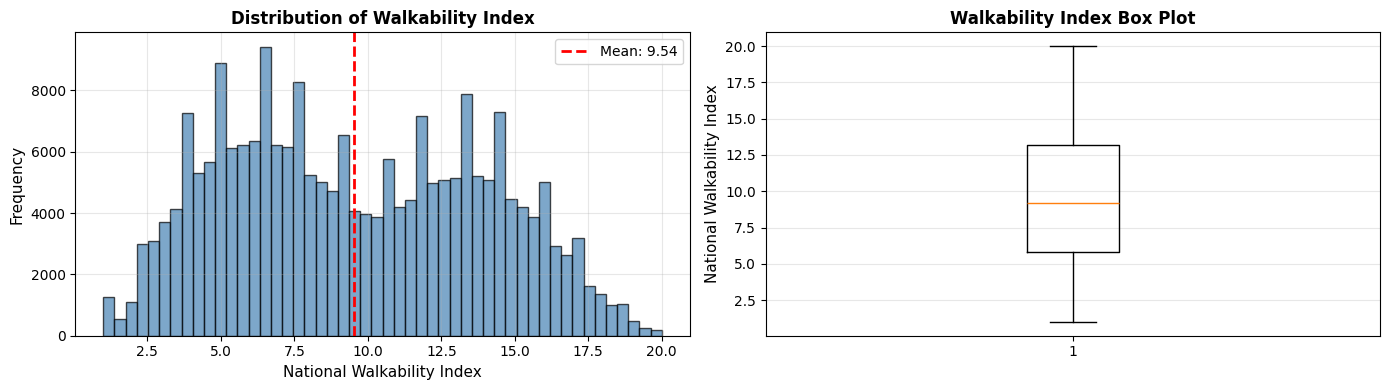

In [8]:
import matplotlib.pyplot as plt # Import matplotlib

df_model = normalized_df.copy() # Define df_model from the previously loaded normalized_df

# Examine target distribution
print("="*60)
print(f"TARGET VARIABLE: {target}")
print("="*60)

target_stats = df_model[target].describe()
display(target_stats)

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df_model[target], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('National Walkability Index', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Walkability Index', fontsize=12, fontweight='bold')
axes[0].axvline(df_model[target].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {df_model[target].mean():.2f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df_model[target], vert=True)
axes[1].set_ylabel('National Walkability Index', fontsize=11)
axes[1].set_title('Walkability Index Box Plot', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Explore Correlations

Analyze the relationships between our selected features and the `NatWalkInd` target variable using correlation coefficients.

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

print("="*60)
print("FEATURE-TARGET CORRELATIONS")
print("="*60)

# Calculate the correlation matrix with the new all_features
correlation_matrix = df_model[all_features + [target]].corr()

# Get correlations with the target variable
target_correlations = correlation_matrix[target].sort_values(ascending=False)

print("Correlations with National Walkability Index (NatWalkInd):")
display(target_correlations)

FEATURE-TARGET CORRELATIONS
Correlations with National Walkability Index (NatWalkInd):


,NatWalkInd
NatWalkInd,1.000000
D4A,0.832707
D3B,0.653552
D5AR,0.491300
D5AE,0.482040
D1B,0.268025
D1A,0.248304
TotEmp,0.127034
D1C,0.084175
Workers,0.032368


### -Visualizing Top Correlations


/tmp/ipython-input-2473871244.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_correlations.drop(target).values, y=target_correlations.drop(target).index, palette='viridis')


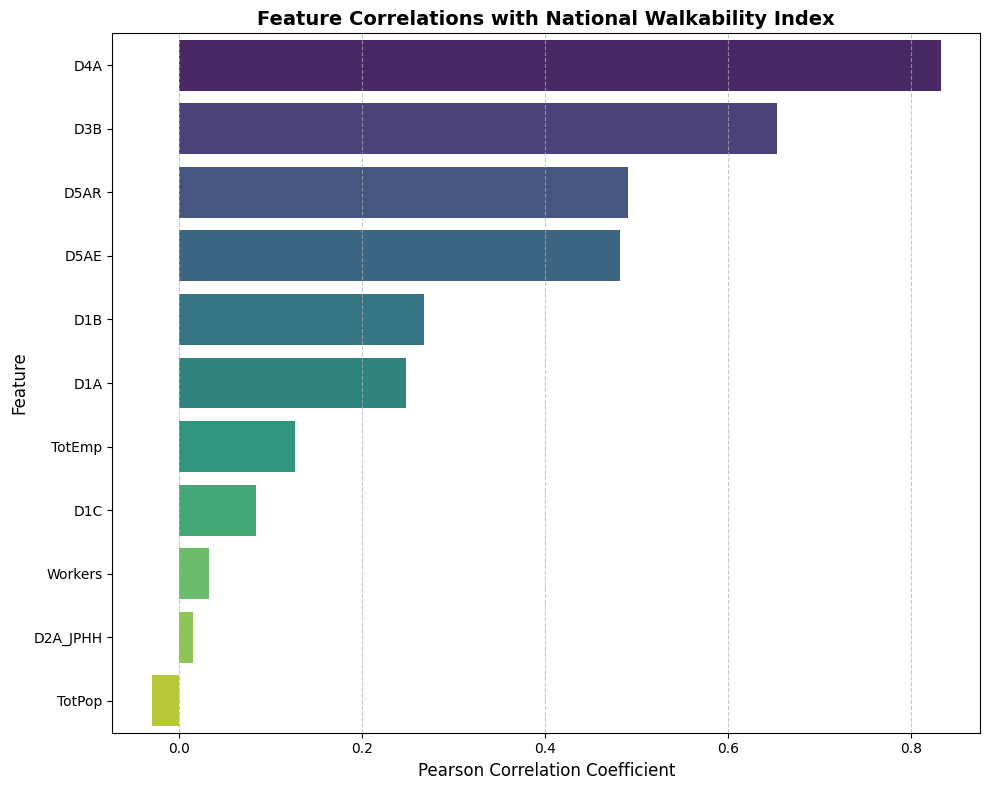

In [10]:
plt.figure(figsize=(10, 8))
sns.barplot(x=target_correlations.drop(target).values, y=target_correlations.drop(target).index, palette='viridis')
plt.title('Feature Correlations with National Walkability Index', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 7. Bayesian optimization (with Random Forest)
Automates the hyperparameter tuning process for a Random Forest Regressor using the Optuna optimization framework. Designed to balance computational efficiency with model accuracy, the code first implements a smart downsampling strategy: if the training dataset exceeds 30,000 records, it generates a stratified subset based on the target variable's distribution (using quantiles) to ensure the optimization runs quickly without losing representative data patterns. The core logic is encapsulated in an objective function that defines a search space for key parameters—including the number of trees (`n_estimators`), tree depth (`max_depth`), and split criteria—and evaluates each configuration using 3-fold cross-validation. The script executes 10 trials using a Tree-Structured Parzen Estimator (TPE) sampler to iteratively maximize the R² score, ultimately printing the most effective combination of hyperparameters to be used in the final model.

In [11]:
try:
    import optuna
    print("✅ Optuna is already installed")
except ImportError:
    print("Installing Optuna...")
    !pip install optuna
    import optuna
    print("✅ Optuna installed successfully")

optuna.logging.set_verbosity(optuna.logging.WARNING)

import numpy as np # Ensure numpy is imported
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score # Import cross_val_score

print("="*60)
print("HYPERPARAMETER TUNING WITH OPTUNA (** Normally about 10 minutes **)")
print("="*60)

sample_size = 30000

# Use the globally defined X_train and y_train for Optuna sampling
if len(X_train) > sample_size:
    # Stratified sampling based on target variable to maintain distribution
    from sklearn.model_selection import train_test_split
    X_optuna, _, y_optuna, _ = train_test_split(
        X_train, y_train, train_size=sample_size, random_state=42, stratify=pd.qcut(y_train, q=5, duplicates='drop')
    )
else:
    X_optuna = X_train
    y_optuna = y_train

# Define the objective function for Optuna
def objective(trial):
    """
    Objective function for Optuna to optimize.
    """
    # Suggest hyperparameters with focused ranges
    params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [100, 150, 200, 250]),
        'max_depth': trial.suggest_categorical('max_depth', [15, 20, 25, 30, None]),
        'min_samples_split': trial.suggest_categorical('min_samples_split', [2, 5, 10]),
        'min_samples_leaf': trial.suggest_categorical('min_samples_leaf', [1, 2, 4]),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': 42,
        'n_jobs': -1
    }

    # Create model with suggested parameters
    model = RandomForestRegressor(**params)

    # Evaluate with cross-validation
    cv_scores = cross_val_score(
        model, X_optuna, y_optuna,
        cv=3,
        scoring='r2',
        n_jobs=-1
    )

    score = cv_scores.mean()

    # Print progress
    print(f"Trial {trial.number:2d}: R² = {score:.4f} | n_est={params['n_estimators']}, max_d={params['max_depth']}, min_split={params['min_samples_split']}")

    return score

# Create Optuna study and optimize
print("Starting Bayesian optimization...")
print("Each trial tests different hyperparameters...\n")

study = optuna.create_study(
    direction='maximize',
    study_name='rf_walkability_optimization',
    sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=5)
)

import time
start_time = time.time()

study.optimize(
    objective,
    n_trials=10,
    show_progress_bar=False,
    n_jobs=1,
    gc_after_trial=True
)

elapsed_time = time.time() - start_time

print(f"\n Optimization Complete!")

# %%
# Display best parameters and results
print("="*60)
print("OPTIMIZATION RESULTS")
print("="*60)
print(f"Number of trials: {len(study.trials)}")
print(f"Best trial number: {study.best_trial.number}")
print(f"Best cross-validation R²: {study.best_value:.4f}")

print("\n" + "="*60)
print("BEST PARAMETERS FOUND")
print("="*60)
best_params = study.best_params
for param, value in best_params.items():
    print(f"  {param}: {value}")


Installing Optuna...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 11.0 MB/s eta 0:00:00
✅ Optuna installed successfully
HYPERPARAMETER TUNING WITH OPTUNA (** Normally about 10 minutes **)
Starting Bayesian optimization...
Each trial tests different hyperparameters...

Trial  0: R² = 0.9403 | n_est=150, max_d=30, min_split=10
Trial  1: R² = 0.9404 | n_est=250, max_d=None, min_split=10
Trial  2: R² = 0.9398 | n_est=100, max_d=15, min_split=2
Trial  3: R² = 0.9401 | n_est=150, max_d=15, min_split=10
Trial  4: R² = 0.9403 | n_est=150, max_d=20, min_split=5
Trial  5: R² = 0.9404 | n_est=250, max_d=None, min_split=10
Trial  6: R² = 0.9405 | n_est=250, max_d=None, min_split=2
Trial  7: R² = 0.9404 | n_est=200, max_d=25, min_split=2
Trial  8: R² = 0.9405 | n_est=250, max_d=None, min_split=2
Trial  9: R² = 0.9404 | n_est=200, max_d=20, min_split=5

 Optimization Complete!
OPTIMIZATION RESULTS
Number of trials: 10
Best trial number: 6
Best cross-validation R²: 0.9405

BEST PARAMETE

## 8. XGBoosting
Define a `KFold` cross-validation strategy, then use Optuna to tune the hyperparameters of an `XGBRegressor` model on a sampled subset of the training data (`X_optuna`, `y_optuna`) using the `KFold` strategy. After tuning, train the `XGBRegressor` with the optimal hyperparameters on the full training set (`X_train`, `y_train`) and evaluate its performance on the test set (`X_test`, `y_test`). Subsequently, train a `RandomForestRegressor` with its previously determined optimal hyperparameters on the full training set and evaluate it on the test set. Finally, compare the performance of both models using R², MAE, and RMSE metrics, and summarize the findings to identify which model performed better for predicting the National Walkability Index.

### Define Cross-Validation Strategy
Create a `KFold` cross-validation strategy object with `n_splits=5`, `shuffle=True`, and `random_state=42`. This object will be used for hyperparameter tuning and evaluation of both XGBoost and Random Forest to ensure a fair comparison on the same data splits.


In [12]:
from sklearn.model_selection import KFold

# Instantiate KFold with the specified parameters
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("KFold cross-validation object created successfully.")
print(f"Number of splits: {kf.n_splits}")
print(f"Shuffle: {kf.shuffle}")
print(f"Random state: {kf.random_state}")

KFold cross-validation object created successfully.
Number of splits: 5
Shuffle: True
Random state: 42


Tune the hyperparameters of an XGBRegressor model using Optuna, incorporating the previously defined KFold cross-validation strategy. This involves setting up an objective function for Optuna that uses the XGBRegressor and the `kf` object for cross-validation on a sampled subset of the training data.



In [13]:
import xgboost as xgb
import optuna
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

optuna.logging.set_verbosity(optuna.logging.WARNING)

print("="*60)
print("XGBOOST HYPERPARAMETER TUNING WITH OPTUNA")
print("="*60)

# Define the objective function for Optuna for XGBoost
def objective_xgb(trial):
    """
    Objective function for Optuna to optimize XGBoost hyperparameters.
    """
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 0.5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42,
        'n_jobs': -1
    }

    model = xgb.XGBRegressor(**params)

    # Evaluate with KFold cross-validation
    r2_scores = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_optuna, y_optuna)):
        X_train_fold, X_val_fold = X_optuna.iloc[train_idx], X_optuna.iloc[val_idx]
        y_train_fold, y_val_fold = y_optuna.iloc[train_idx], y_optuna.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)
        preds = model.predict(X_val_fold)
        r2_scores.append(r2_score(y_val_fold, preds))

    score = np.mean(r2_scores)

    print(f"Trial {trial.number:2d}: R² = {score:.4f} | lr={params['learning_rate']:.3f}, max_d={params['max_depth']}")

    return score

# Create Optuna study and optimize for XGBoost
print("Starting Bayesian optimization for XGBoost...")
print("Each trial tests different hyperparameters...\n")

study_xgb = optuna.create_study(
    direction='maximize',
    study_name='xgb_walkability_optimization',
    sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=5)
)

import time
start_time_xgb = time.time()

study_xgb.optimize(
    objective_xgb,
    n_trials=10,
    show_progress_bar=False,
    n_jobs=1,
    gc_after_trial=True
)

elapsed_time_xgb = time.time() - start_time_xgb

print(f"\n Optimization Complete!")

# Display best parameters and results for XGBoost
print("="*60)
print("XGBOOST OPTIMIZATION RESULTS")
print("="*60)
print(f"Number of trials: {len(study_xgb.trials)}")
print(f"Best trial number: {study_xgb.best_trial.number}")
print(f"Best cross-validation R²: {study_xgb.best_value:.4f}")

print("\n" + "="*60)
print("BEST XGBOOST PARAMETERS FOUND")
print("="*60)
best_params_xgb = study_xgb.best_params
for param, value in best_params_xgb.items():
    print(f"  {param}: {value}")

# Train the final XGBoost model with optimal hyperparameters on the full training set
print("\n" + "="*60)
print("TRAINING FINAL XGBOOST MODEL")
print("="*60)
final_xgb_model = xgb.XGBRegressor(**best_params_xgb, random_state=42, n_jobs=-1)
final_xgb_model.fit(X_train, y_train)
print("Final XGBoost model trained.")

# Evaluate XGBoost model on the test set
print("\n" + "="*60)
print("XGBOOST TEST SET EVALUATION")
print("="*60)
y_pred_xgb = final_xgb_model.predict(X_test)

r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"XGBoost R² on Test Set: {r2_xgb:.4f}")
print(f"XGBoost MAE on Test Set: {mae_xgb:.4f}")
print(f"XGBoost RMSE on Test Set: {rmse_xgb:.4f}")

# Train the final RandomForest model with optimal hyperparameters on the full training set
# (using 'best_params' which was determined in cell xN3mhTyZ5Eip)
print("\n" + "="*60)
print("TRAINING FINAL RANDOM FOREST MODEL")
print("="*60)
final_rf_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
final_rf_model.fit(X_train, y_train)
print("Final Random Forest model trained.")

# Evaluate RandomForest model on the test set
print("\n" + "="*60)
print("RANDOM FOREST TEST SET EVALUATION")
print("="*60)
y_pred_rf = final_rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest R² on Test Set: {r2_rf:.4f}")
print(f"Random Forest MAE on Test Set: {mae_rf:.4f}")
print(f"Random Forest RMSE on Test Set: {rmse_rf:.4f}")

# Summary and Comparison
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print("                     R²     MAE     RMSE")
print(f"XGBoost          {r2_xgb:.4f}  {mae_xgb:.4f}  {rmse_xgb:.4f}")
print(f"Random Forest    {r2_rf:.4f}  {mae_rf:.4f}  {rmse_rf:.4f}")

if r2_xgb > r2_rf:
    print("\nXGBoost performed better on the test set in terms of R².")
elif r2_rf > r2_xgb:
    print("\nRandom Forest performed better on the test set in terms of R².")
else:
    print("\nBoth models performed similarly on the test set in terms of R².")


XGBOOST HYPERPARAMETER TUNING WITH OPTUNA
Starting Bayesian optimization for XGBoost...
Each trial tests different hyperparameters...

Trial  0: R² = 0.9316 | lr=0.254, max_d=8
Trial  1: R² = 0.9398 | lr=0.077, max_d=8
Trial  2: R² = 0.8994 | lr=0.019, max_d=5
Trial  3: R² = 0.9335 | lr=0.027, max_d=5
Trial  4: R² = 0.9356 | lr=0.012, max_d=7
Trial  5: R² = 0.9376 | lr=0.110, max_d=10
Trial  6: R² = 0.9438 | lr=0.064, max_d=3
Trial  7: R² = 0.9427 | lr=0.040, max_d=3
Trial  8: R² = 0.9429 | lr=0.176, max_d=3
Trial  9: R² = 0.9440 | lr=0.054, max_d=5

 Optimization Complete!
XGBOOST OPTIMIZATION RESULTS
Number of trials: 10
Best trial number: 9
Best cross-validation R²: 0.9440

BEST XGBOOST PARAMETERS FOUND
  n_estimators: 300
  learning_rate: 0.05429358718036803
  max_depth: 5
  subsample: 0.914168525215687
  colsample_bytree: 0.8646089776541122
  gamma: 0.22617274536189486
  min_child_weight: 4

TRAINING FINAL XGBOOST MODEL
Final XGBoost model trained.

XGBOOST TEST SET EVALUATION
XGB

### Compare Model Performance

Generate a comparative summary of the performance metrics (R², MAE, RMSE) for both the tuned XGBoost and Random Forest models. Visualize the comparison of these metrics, for instance, using a bar plot, to highlight their relative strengths and weaknesses.


from matplotlib import pyplot as plt
_df_10['R²'].plot(kind='line', figsize=(8, 4), title='R²')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_11['MAE'].plot(kind='line', figsize=(8, 4), title='MAE')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_12['RMSE'].plot(kind='line', figsize=(8, 4), title='RMSE')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_13['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_13, x='R²', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_14['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_14, x='MAE', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_15['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_15, x='RMSE', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)


MODEL PERFORMANCE SUMMARY


,R²,MAE,RMSE
XGBoost,0.946504,0.801671,1.013011
Random Forest,0.944737,0.813967,1.029605


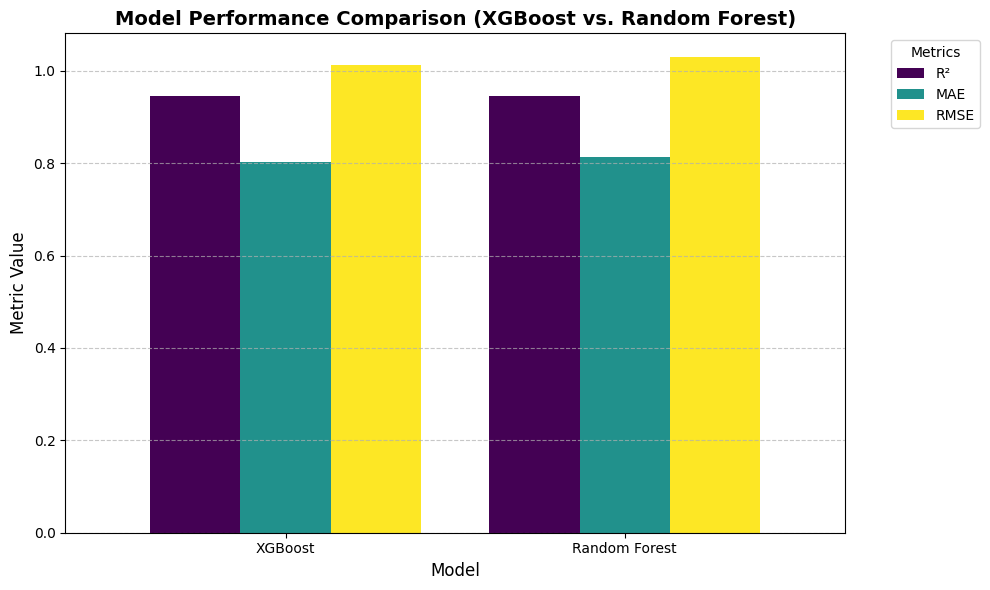


QUALITATIVE COMPARISON
XGBoost generally performed better with higher R-squared and lower MAE/RMSE.


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Assuming r2_xgb, mae_xgb, rmse_xgb, r2_rf, mae_rf, rmse_rf are already defined
# (from the previous code execution)

# Create a DataFrame to store the metrics
performance_data = {
    'R²': [r2_xgb, r2_rf],
    'MAE': [mae_xgb, mae_rf],
    'RMSE': [rmse_xgb, rmse_rf]
}

model_names = ['XGBoost', 'Random Forest']
performance_df = pd.DataFrame(performance_data, index=model_names)

print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
display(performance_df)

# Plotting the comparison
fig, ax = plt.subplots(figsize=(10, 6))
performance_df.plot(kind='bar', ax=ax, colormap='viridis', width=0.8)

ax.set_title('Model Performance Comparison (XGBoost vs. Random Forest)', fontsize=14, fontweight='bold')
ax.set_ylabel('Metric Value', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("QUALITATIVE COMPARISON")
print("="*60)
if r2_xgb > r2_rf and mae_xgb < mae_rf and rmse_xgb < rmse_rf:
    print("XGBoost generally performed better with higher R-squared and lower MAE/RMSE.")
elif r2_rf > r2_xgb and mae_rf < mae_xgb and rmse_rf < rmse_xgb:
    print("Random Forest generally performed better with higher R-squared and lower MAE/RMSE.")
elif r2_xgb >= r2_rf and (mae_xgb <= mae_rf or rmse_xgb <= rmse_rf):
    print("XGBoost shows slightly better performance, particularly with its higher R-squared and lower error metrics.")
elif r2_rf >= r2_xgb and (mae_rf <= mae_xgb or rmse_rf <= rmse_xgb):
    print("Random Forest shows slightly better performance, particularly with its higher R-squared and lower error metrics.")
else:
    print("Both models performed very similarly, with minor differences in specific metrics.")


## 9. cluster with k-means

Clustering Data Shape: (220740, 7)
------------------------------------------------------------
Running Elbow Method to find optimal K...


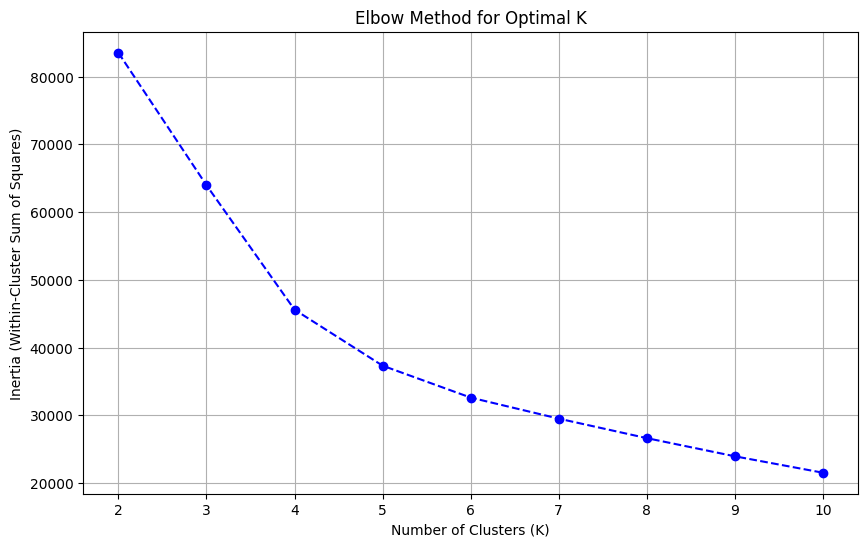

Fitting K-Means with K=5...

Cluster Centers (Mean values of normalized features):
                D1A_normalized  D1B_normalized  D1C_normalized  \
Cluster_KMeans                                                   
0                     0.004019        0.004572        0.000355   
1                     0.000833        0.000913        0.000062   
2                     0.026633        0.841597        0.892938   
3                     0.050529        0.049945        0.004317   
4                     0.000012        0.000677        0.006909   

                D2A_JPHH_normalized  D3B_normalized  D4A_normalized  \
Cluster_KMeans                                                        
0                          0.000173        0.023695        0.976468   
1                          0.000095        0.008009        0.000000   
2                          0.007215        0.049215        0.990698   
3                          0.000208        0.022733        0.984135   
4                          0

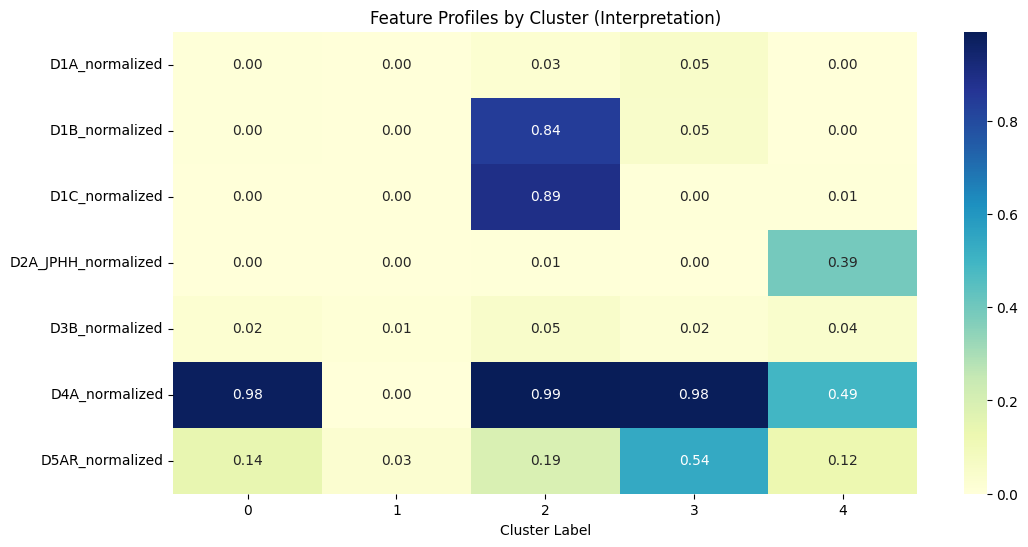

------------------------------------------------------------
Running Hierarchical Clustering...
Sampling 10000 random points for Dendrogram visualization...


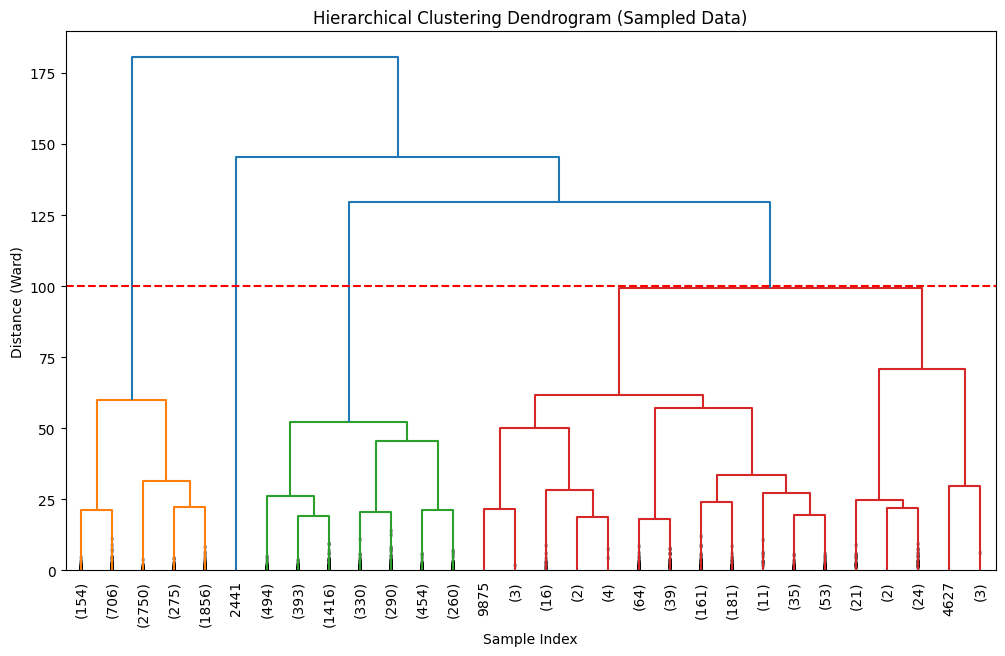

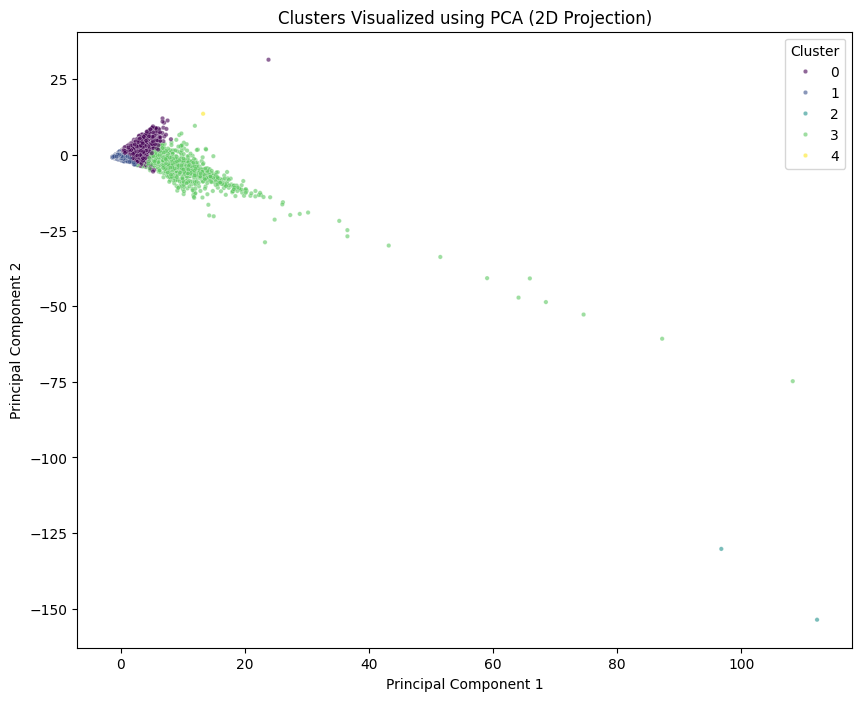

Analysis Complete.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# ==============================================================================
# 1. SETUP AND FEATURE SELECTION
# ==============================================================================
# Load the normalized data created in your previous steps
df = pd.read_csv('EPA_SmartLocationDatabase_V3_CLEANED_NORMALIZED.csv')

# Select features relevant for "Neighborhood Type"
# We focus on the "D" variables (Density, Design, Diversity, Distance, Destination)
# We drop identifiers (GEOID) and raw counts (TotPop) to focus on the *characteristics* of the area.
cluster_features = [
    'D1A_normalized',      # Residential Density
    'D1B_normalized',      # Employment Density
    'D1C_normalized',      # Activity Density
    'D2A_JPHH_normalized', # Jobs-Housing Balance
    'D3B_normalized',      # Street Intersection Density (Walkability)
    'D4A_normalized',      # Distance to Transit
    'D5AR_normalized'      # Regional Accessibility
]

# Create the feature matrix
X = df[cluster_features].copy()

# Even though data is 0-1 normalized, it is often good practice to use StandardScaler
# for Clustering to handle variance, but since your D-variables are already
# strictly normalized 0-1, we can proceed with X directly or scale it.
# Let's scale it to Z-scores to ensure outliers don't dominate the variance.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Clustering Data Shape: {X_scaled.shape}")
print("-" * 60)

# ==============================================================================
# 2. K-MEANS: ELBOW METHOD
# ==============================================================================
print("Running Elbow Method to find optimal K...")

inertia = []
K_range = range(2, 11)  # Test K from 2 to 10

# We use a subset for the Elbow method to speed up rendering if dataset is huge
sample_indices = np.random.choice(X_scaled.shape[0], size=min(20000, X_scaled.shape[0]), replace=False)
X_sample = X_scaled[sample_indices]

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_sample)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

# ==============================================================================
# 3. K-MEANS: FINAL MODEL
# ==============================================================================
# Based on typical urban data, K=4 or K=5 is usually the "elbow".
# Let's assume K=5 for categorization (e.g., Rural, Exurb, Suburb, Urban, Core)
optimal_k = 5
print(f"Fitting K-Means with K={optimal_k}...")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans_final.fit_predict(X_scaled)

# Analyze the clusters
print("\nCluster Centers (Mean values of normalized features):")
cluster_summary = df.groupby('Cluster_KMeans')[cluster_features].mean()
print(cluster_summary)

# Visualizing Cluster Profiles (Heatmap)
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_summary.T, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title('Feature Profiles by Cluster (Interpretation)')
plt.xlabel('Cluster Label')
plt.show()

# ==============================================================================
# 4. HIERARCHICAL CLUSTERING (DENDROGRAM)
# ==============================================================================
print("-" * 60)
print("Running Hierarchical Clustering...")

# CRITICAL: Hierarchical clustering is O(N^2). It will crash on 220k rows.
# We MUST sample the data to visualize the dendrogram.
dendro_sample_size = 10000
print(f"Sampling {dendro_sample_size} random points for Dendrogram visualization...")

sample_idx = np.random.choice(len(X_scaled), size=dendro_sample_size, replace=False)
X_dendro = X_scaled[sample_idx]

# Calculate Linkage Matrix (Ward method minimizes variance)
Z = linkage(X_dendro, method='ward')

# Plot Dendrogram
plt.figure(figsize=(12, 7))
plt.title("Hierarchical Clustering Dendrogram (Sampled Data)")
plt.xlabel("Sample Index")
plt.ylabel("Distance (Ward)")
dendrogram(
    Z,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=30,                   # show only the last 30 merges
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.axhline(y=100, color='r', linestyle='--') # Arbitrary cut-off line for visualization
plt.show()

# ==============================================================================
# 5. VISUALIZATION: PCA
# ==============================================================================
# To visualize the 7-dimensional clusters in 2D space
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df['Cluster_KMeans'],
    palette='viridis',
    alpha=0.6,
    s=10
)
plt.title('Clusters Visualized using PCA (2D Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

print("Analysis Complete.")